##### ARTI 560 - Computer Vision

## Visual Representations with DINOv2 - Exercise

### Exercise 1: Unsupervised Clustering

In this exercise, you will use the `KMeans` algorithm from sklearn to group 20 images from the Oxford Pet dataset into 2 clusters (Cats vs. Dogs) based purely on their CLS tokens.

Instructions:

1.  Extract the 384-dimensional [CLS] tokens from 20 images of the Oxford-IIIT Pet dataset. Ensure your selection includes a mix of both cats and dogs.

2. Apply K-Means Clustering ($n=2$) to group the vectors based on mathematical similarity rather than provided labels.

3. Compare the predicted clusters against ground-truth labels.

In [1]:
# Provide your solution here

import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from PIL import Image
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, confusion_matrix
from transformers import AutoImageProcessor, AutoModel

# Global Configuration
MODEL_ID = "facebook/dinov2-small"
device = "cuda" if torch.cuda.is_available() else "cpu"

# Load DINOv2 feature extractor
processor = AutoImageProcessor.from_pretrained(MODEL_ID)
model = AutoModel.from_pretrained(MODEL_ID).to(device)
model.eval()

print(f"Model {MODEL_ID} loaded on {device}")



/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:103: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/436 [00:00<?, ?B/s]

The image processor of type `BitImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json:   0%|          | 0.00/547 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/88.2M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

Model facebook/dinov2-small loaded on cpu


In [3]:
from torchvision.datasets import OxfordIIITPet

# Download and load the Oxford-IIIT Pet dataset
# binary-category gives two labels: 0 = cat, 1 = dog
dataset = OxfordIIITPet(
    root="data",
    split="trainval",
    target_types="binary-category",
    download=True
)

# Collect 10 cat images and 10 dog images
selected_images = []
true_labels = []
image_names = []

cat_count = 0
dog_count = 0

for i in range(len(dataset)):
    image, label = dataset[i]

    if label == 0 and cat_count < 10:
        selected_images.append(image.convert("RGB"))
        true_labels.append(0)
        image_names.append(f"cat_{cat_count + 1}")
        cat_count += 1

    elif label == 1 and dog_count < 10:
        selected_images.append(image.convert("RGB"))
        true_labels.append(1)
        image_names.append(f"dog_{dog_count + 1}")
        dog_count += 1

    if cat_count == 10 and dog_count == 10:
        break

true_labels = np.array(true_labels)

print(f"Number of selected images: {len(selected_images)}")
print(f"Cats: {cat_count}")
print(f"Dogs: {dog_count}")

Number of selected images: 20
Cats: 10
Dogs: 10


In [4]:
@torch.no_grad()
def get_cls_embeddings(images, batch_size=4):
    """Extract normalized DINOv2 [CLS] embeddings for a list of PIL images."""
    all_embeddings = []

    for start in range(0, len(images), batch_size):
        batch_images = images[start:start + batch_size]
        inputs = processor(images=batch_images, return_tensors="pt").to(device)

        outputs = model(**inputs)

        # The first token is the global [CLS] token
        cls_tokens = outputs.last_hidden_state[:, 0, :]

        # Normalize embeddings before similarity-based methods
        cls_tokens = F.normalize(cls_tokens, p=2, dim=1)

        all_embeddings.append(cls_tokens.cpu())

    return torch.cat(all_embeddings, dim=0).numpy()


features = get_cls_embeddings(selected_images)

print("Feature matrix shape:", features.shape)
print("Each image is represented by a 384-dimensional vector.")

Feature matrix shape: (20, 384)
Each image is represented by a 384-dimensional vector.


In [5]:
# Apply K-Means clustering with two clusters
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
cluster_ids = kmeans.fit_predict(features)

# K-Means cluster IDs are arbitrary.
# So we test both possible mappings:
# Option A: cluster 0 = cat, cluster 1 = dog
pred_a = cluster_ids

# Option B: cluster 0 = dog, cluster 1 = cat
pred_b = 1 - cluster_ids

acc_a = accuracy_score(true_labels, pred_a)
acc_b = accuracy_score(true_labels, pred_b)

if acc_a >= acc_b:
    predicted_labels = pred_a
    best_accuracy = acc_a
else:
    predicted_labels = pred_b
    best_accuracy = acc_b

label_names = {0: "Cat", 1: "Dog"}

results = pd.DataFrame({
    "Image": image_names,
    "True Label": [label_names[x] for x in true_labels],
    "Cluster ID": cluster_ids,
    "Predicted Label": [label_names[x] for x in predicted_labels]
})

display(results)

print(f"Clustering accuracy: {best_accuracy:.2f}")
print("Confusion matrix:")
print(confusion_matrix(true_labels, predicted_labels))

,Image,True Label,Cluster ID,Predicted Label
0,cat_1,Cat,0,Cat
1,cat_2,Cat,0,Cat
2,cat_3,Cat,0,Cat
3,cat_4,Cat,0,Cat
4,cat_5,Cat,0,Cat
5,cat_6,Cat,0,Cat
6,cat_7,Cat,0,Cat
7,cat_8,Cat,0,Cat
8,cat_9,Cat,0,Cat
9,cat_10,Cat,0,Cat


Clustering accuracy: 1.00
Confusion matrix:
[[10  0]
 [ 0 10]]


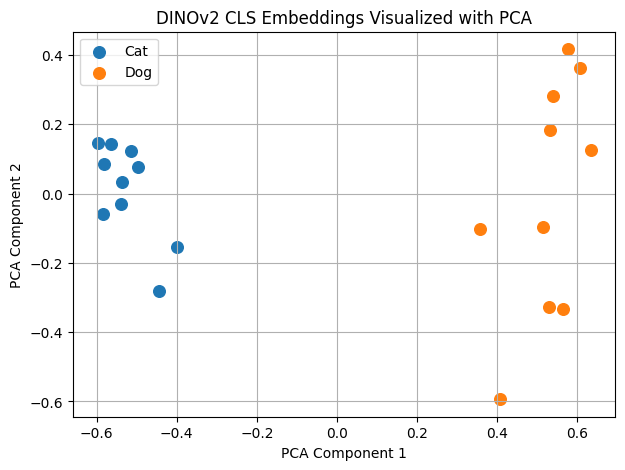

In [6]:
# Visualize the 384-dimensional embeddings in 2D using PCA
pca = PCA(n_components=2, random_state=42)
features_2d = pca.fit_transform(features)

plt.figure(figsize=(7, 5))

for label_value, label_name in label_names.items():
    mask = true_labels == label_value
    plt.scatter(
        features_2d[mask, 0],
        features_2d[mask, 1],
        label=label_name,
        s=70
    )

plt.title("DINOv2 CLS Embeddings Visualized with PCA")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend()
plt.grid(True)
plt.show()

### Exercise 2: Image Classification with DINOv2

In this exercise you'll use a DINOv2 model with a pre-trained linear head to classify an image. You will observe how the model maps visual features to specific ImageNet-1k categories.

Instructions:
1. For this exercise, you must use the following Model ID. This specific checkpoint includes the necessary classification head trained on ImageNet-1k:

    Model ID: `facebook/dinov2-small-imagenet1k-1-layer`

2. Find an image online to make the inference. To ensure the model has a fair chance of success, the image should belong to one of the ImageNet-1k classes (e.g., a Golden Retriever, a grand piano, a school bus, or a coffee mug).

In [7]:
# Provide your solution here
import requests
from transformers import AutoModelForImageClassification

# Required model for this exercise
CLASSIFICATION_MODEL_ID = "facebook/dinov2-small-imagenet1k-1-layer"

classification_processor = AutoImageProcessor.from_pretrained(CLASSIFICATION_MODEL_ID)
classification_model = AutoModelForImageClassification.from_pretrained(
    CLASSIFICATION_MODEL_ID
).to(device)

classification_model.eval()

print(f"Classification model {CLASSIFICATION_MODEL_ID} loaded on {device}")

preprocessor_config.json:   0%|          | 0.00/436 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/91.3M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/225 [00:00<?, ?it/s]

Classification model facebook/dinov2-small-imagenet1k-1-layer loaded on cpu


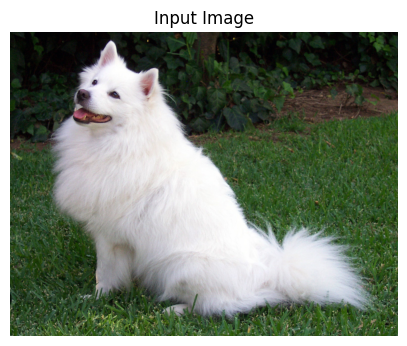

In [8]:
# Online image example from PyTorch Hub
# This image contains a dog, which belongs to ImageNet-style categories.
image_url = "https://raw.githubusercontent.com/pytorch/hub/master/images/dog.jpg"

image = Image.open(requests.get(image_url, stream=True).raw).convert("RGB")

plt.figure(figsize=(5, 5))
plt.imshow(image)
plt.axis("off")
plt.title("Input Image")
plt.show()

In [9]:
# Run inference
inputs = classification_processor(images=image, return_tensors="pt").to(device)

with torch.no_grad():
    outputs = classification_model(**inputs)
    logits = outputs.logits
    probabilities = torch.softmax(logits, dim=1)

# Get Top-5 predictions
top5 = torch.topk(probabilities, k=5)

print("Top-5 Predictions:")
for rank, (score, class_id) in enumerate(zip(top5.values[0], top5.indices[0]), start=1):
    class_name = classification_model.config.id2label[class_id.item()]
    print(f"{rank}. {class_name}: {score.item():.4f}")

Top-5 Predictions:
1. Samoyed, Samoyede: 0.6740
2. Pomeranian: 0.2570
3. keeshond: 0.0247
4. Great Pyrenees: 0.0136
5. Japanese spaniel: 0.0093
